# Load notebook

### Python modules

In [341]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout
from scipy.ndimage import binary_dilation

from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Load e4m masks

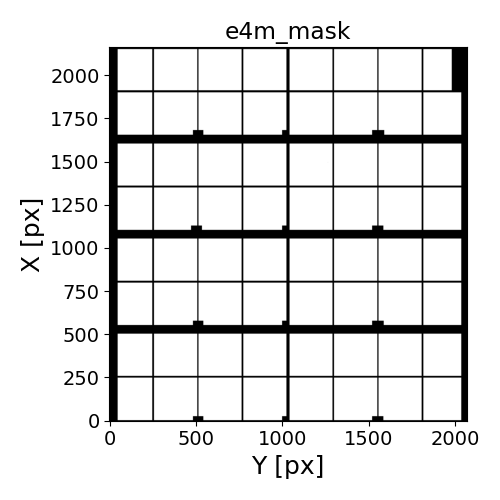

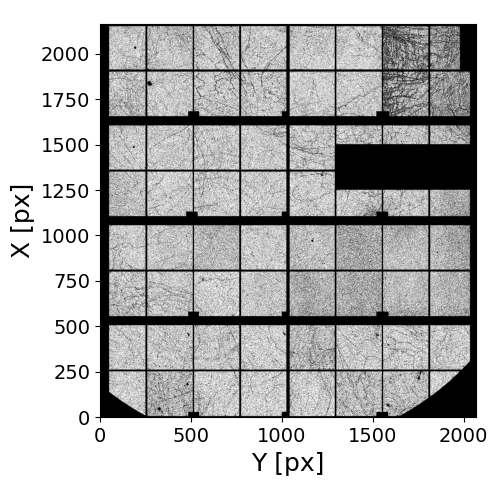

In [342]:
### e4m MASKS
e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.title('e4m_mask')
plt.tight_layout(); plt.show()

### ht MASK
e4m_htmask_GeO2_7_30C  = np.load(MASKS_folder+'e4m_htmask-GeO2_7_30C_0003_0003' +'.npy')
e4m_htmask_GeO2_7_100C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_100C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_170C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_170C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_240C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_240C_0001_0003'+'.npy')
e4m_htmask = e4m_htmask_GeO2_7_30C * e4m_htmask_GeO2_7_100C * e4m_htmask_GeO2_7_170C * e4m_htmask_GeO2_7_240C

e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask*e4m_htmask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

## Load data

### Beamstop mask

#################################################
Masked area =  93.74594052000708 %
#################################################



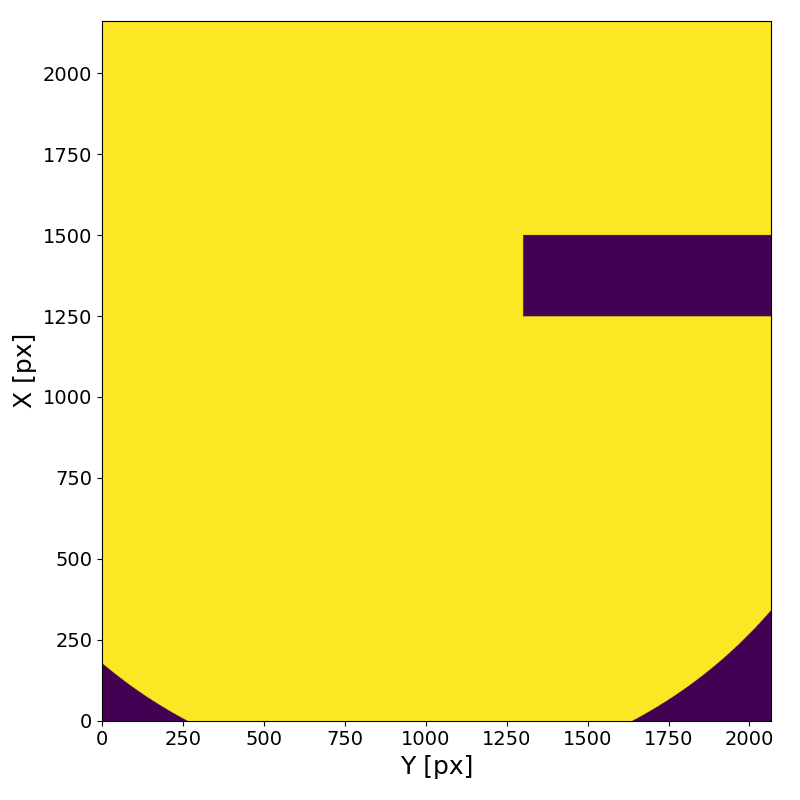

In [343]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
bs_mask = XPCS.gen_mask(mask_geom=geom)

### XPCS scan 4 analyisis

In [344]:
#######################################
sample_name = 'GeO2_3_555C'
Ndataset = 1
Nscan = 4
#######################################

In [369]:
#######################################
Nfi, Nff = 1000, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=3)

#############################
command = mtimescan 0.001 1 6000048
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 110.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00048.h5 (49/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00024.h5 (25/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00033.h5 (34/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00025.h5 (26/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00014.h5 (15/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00039.h5 (40/1201 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00047.h5 (48/1201 loops)
	 -> loading file eiger4m_v2_spars

In [370]:
####################
Lbin = 10
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

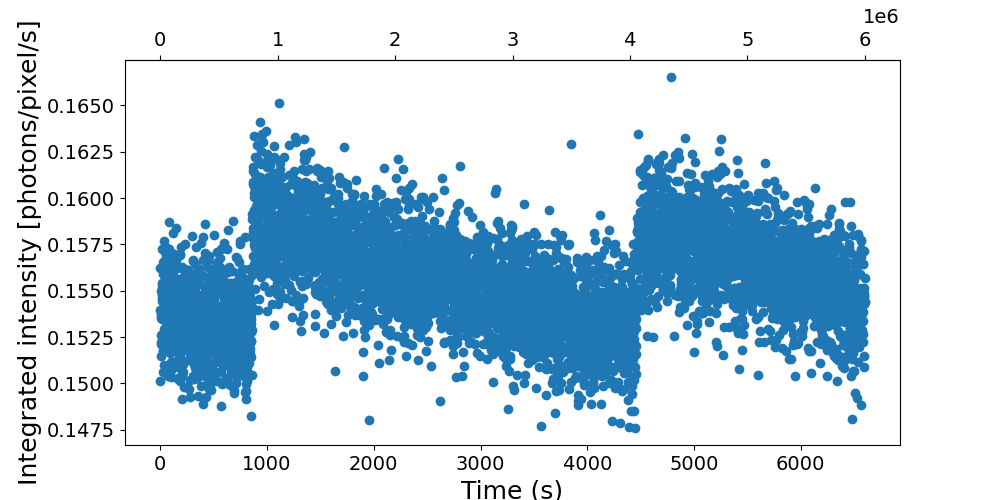

In [371]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### BKG scan 4 analyisis

In [372]:
#######################################
sample_name_bkg = 'GeO2_6q_delcoup_1'
Ndataset_bkg = 1
Nscan_bkg = 2
#######################################

In [373]:
#######################################
Nfi, Nff = int(2.7e6), None
#######################################

scan_bkg = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei_bkg = scan_bkg['monoe']
itime_bkg = scan_bkg['fast_timer_period'][0]
theta_bkg = scan_bkg['delcoup']
Q_bkg = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan_bkg['command'])
print('Ei =', Ei_bkg)
print('itime =', itime_bkg)
print('theta =', theta_bkg)
print('Q =', Q_bkg)
print('T = {:.2f} min'.format(len(scan_bkg['fast_timer_period'])*itime_bkg/60))   
print('#############################\n')

e4m_data_bkg = ID10.load_sparse_e4m(RAW_folder, sample_name_bkg, Ndataset_bkg, Nscan_bkg, Nfi, Nff,  n_jobs=50)
e4m_data_bkg = COSMIC.fast_gamma_filter(e4m_data_bkg, Imaxth_high=3)

#############################
command = mtimescan 0.001 1 6000048
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 110.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00540.h5 (541/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00541.h5 (542/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00542.h5 (543/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00543.h5 (544/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00544.h5 (545/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00545.h5 (546/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00546.h5 (547/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00547.h5 (548/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00548.h5 (549/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00549.h5 (550/123 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00550.h5 (551/123 loops)
	 -> loading file eiger4m_v2_s

In [374]:
####################
Lbin = 1
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data_bkg, itime_bkg, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

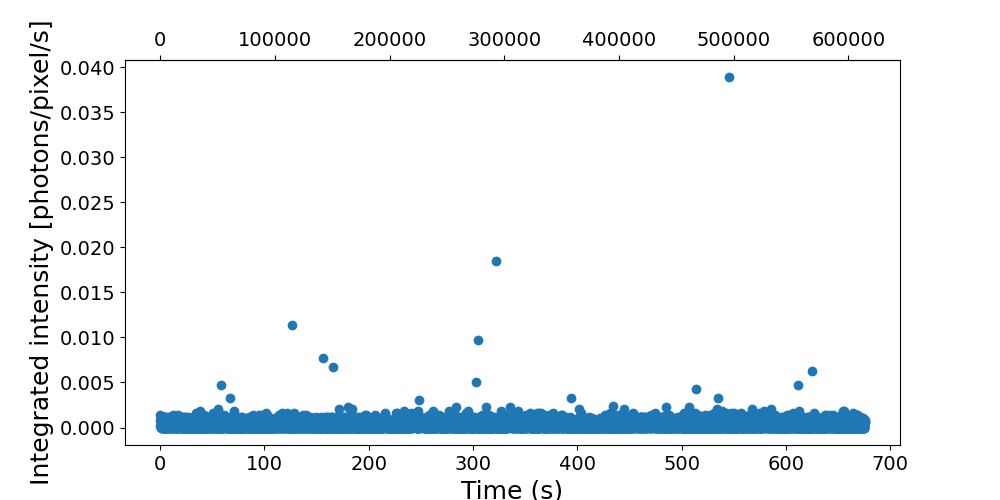

In [375]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

## Cosmic ray removal

In [352]:
CR_removal = False

if CR_removal:
    CR, e4m_data_nocr = COSMIC.cosmic_filter(e4m_data,     Dpx=1, counts_th=1, itime=itime, Nfi=None, Nff=None)
    CR_bkg, e4m_data_bkg_nocr = COSMIC.cosmic_filter(e4m_data_bkg, Dpx=3, counts_th=2, itime=itime_bkg)

In [353]:
i=3

if CR_removal:
    imgA =e4m_data[i].toarray().reshape(Nx, Ny)
    imgA = binary_dilation(imgA, structure=np.ones((5,5)), iterations=1)

    imgB =CR[i].toarray().reshape(Nx, Ny)
    imgB = binary_dilation(imgB, structure=np.ones((20,20)), iterations=1)

    plt.figure(figsize=(10,10))
    plt.imshow(imgB*.5+imgA, cmap='viridis', origin='lower', vmax=1)
    plt.title('Cosmic ray retrieval')

In [354]:
if CR_removal:
    img = CR.sum(axis=0).reshape(Nx, Ny)

    from scipy.ndimage import binary_dilation
    img = binary_dilation(img, structure=np.ones((2,2)), iterations=1)

    plt.figure(figsize=(10,10))
    plt.imshow(img, cmap='viridis', origin='lower', vmax=1)
    plt.title('Cosmic ray retrieval')

## k-mask generation

In [355]:
# k distributions
k = {}
k[1] = e4m_data == 1
k[2] = e4m_data == 2
k[3] = e4m_data == 3
k[4] = e4m_data == 4
k_p= {}
k_p[1] = k[1].sum(axis=0)
k_p[2] = k[2].sum(axis=0)
k_p[3] = k[3].sum(axis=0)
k_p[4] = k[4].sum(axis=0)

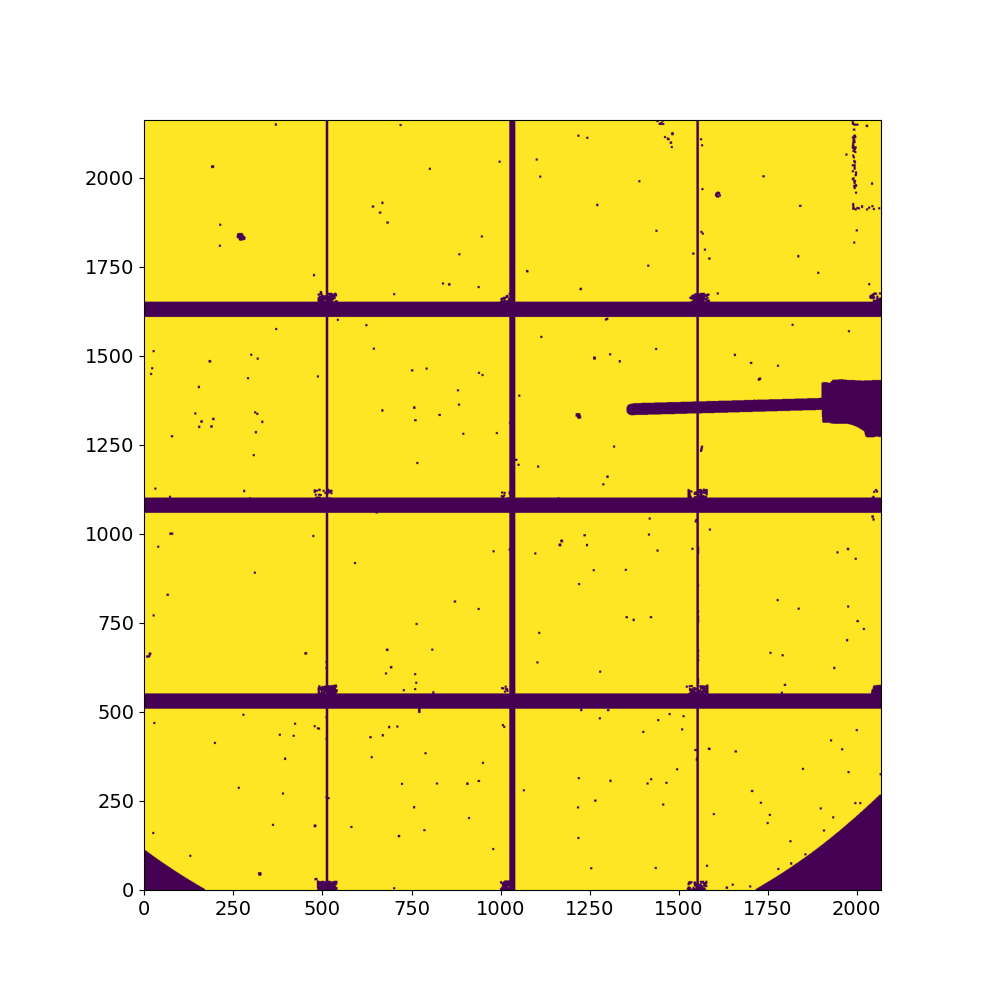

In [356]:
#################
w = 6
e4m_kmask = (k_p[2]<=8)*(k_p[3]<=5)*(k_p[4]<=2) * (k_p[1]/e4m_data.shape[0]>.0001) * (k_p[1]/e4m_data.shape[0]<.0006)
#################

from scipy.ndimage import binary_dilation
e4m_kmask = ~binary_dilation(~e4m_kmask.reshape(Nx, Ny), structure=np.ones((w,w)), iterations=1)
e4m_kmask = e4m_kmask.flatten()

np.save(MASKS_folder  + f'e4m_kmask-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}.npy', e4m_htmask)

plt.figure(figsize=(10,10))
plt.imshow(e4m_kmask.reshape(Nx,Ny), cmap='viridis', origin='lower')

# k-event statistic by pixel

In [357]:
M = e4m_mask*bs_mask*e4m_kmask*e4m_htmask 

In [358]:
# MASKING DATA
e4m_data_M = e4m_data[:,M]
e4m_data_bkg_M = e4m_data_bkg[:,M]

In [331]:
k = {}
k[1] = e4m_data_M == 1
k[2] = e4m_data_M == 2
k[3] = e4m_data_M == 3
k[4] = e4m_data_M == 4

k_bkg = {}
k_bkg[1] = e4m_data_bkg_M == 1
k_bkg[2] = e4m_data_bkg_M == 2
k_bkg[3] = e4m_data_bkg_M == 3
k_bkg[4] = e4m_data_bkg_M == 4

In [332]:
k_p = {}
k_p[1] = k[1].sum(axis=0)/k[1].shape[0]
k_p[2] = k[2].sum(axis=0)/k[1].shape[0]
k_p[3] = k[3].sum(axis=0)/k[1].shape[0]
k_p[4] = k[4].sum(axis=0)/k[1].shape[0]

k_p_bkg = {}
k_p_bkg[1] = k_bkg[1].sum(axis=0)/k_bkg[1].shape[0]
k_p_bkg[2] = k_bkg[2].sum(axis=0)/k_bkg[1].shape[0]
k_p_bkg[3] = k_bkg[3].sum(axis=0)/k_bkg[1].shape[0]
k_p_bkg[4] = k_bkg[4].sum(axis=0)/k_bkg[1].shape[0]

## k = 1

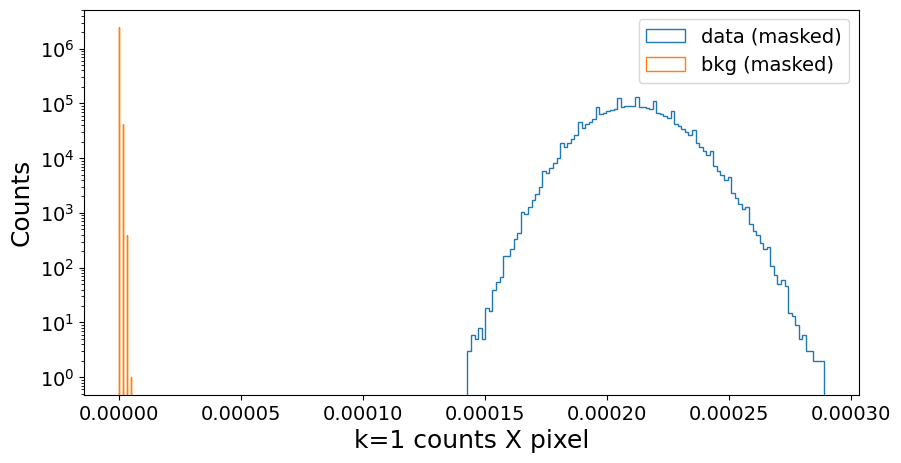

In [115]:
plt.figure(figsize=(10,5))
plt.hist(k_p[1],     bins=100, histtype='step', label='data (masked)',  )
plt.hist(k_p_bkg[1], bins=100, histtype='step',    label='bkg (masked)', )

plt.xlabel('k=1 counts X pixel')
plt.ylabel('Counts')
plt.yscale('log')
#plt.xscale('log')
plt.legend()

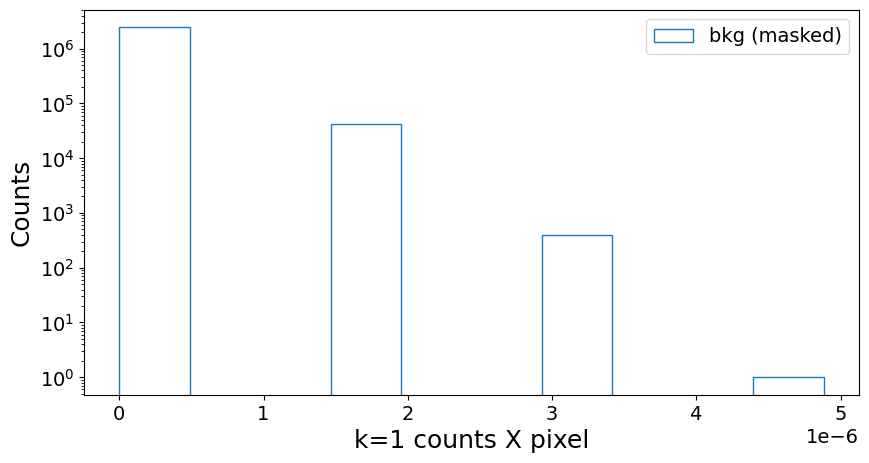

In [116]:
plt.figure(figsize=(10,5))
plt.hist(k_p_bkg[1], bins=10, histtype='step',    label='bkg (masked)', )

plt.xlabel('k=1 counts X pixel')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

## k = 2

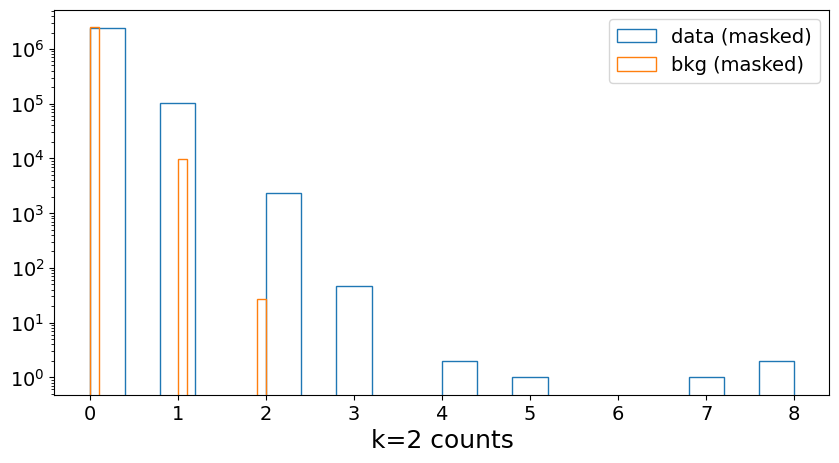

In [117]:
plt.figure(figsize=(10,5))
plt.hist(k_p[2]*k[1].shape[0],     bins=20, histtype='step', label='data (masked)' )
plt.hist(k_p_bkg[2]*k_bkg[1].shape[0], bins=20, histtype='step', label='bkg (masked)')

plt.xlabel('k=2 counts')
plt.yscale('log')
plt.legend()

## k = 3

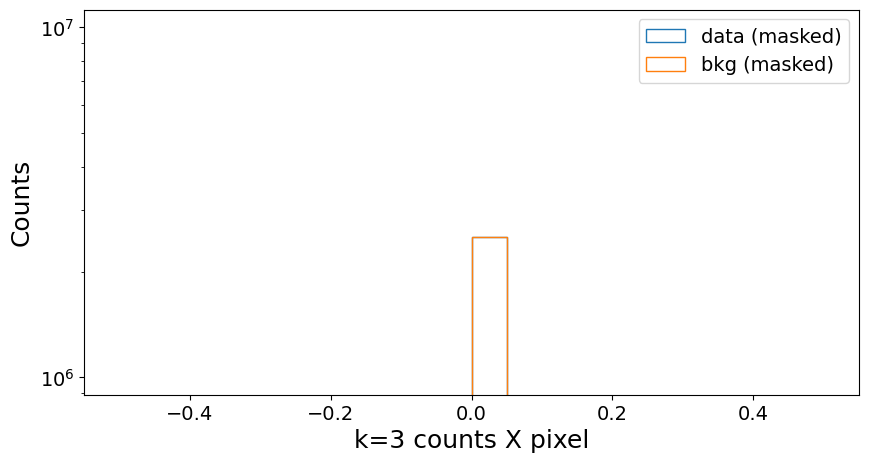

In [118]:
plt.figure(figsize=(10,5))
plt.hist(k_p[3]*k[1].shape[0],     bins=20, histtype='step', label='data (masked)' )
plt.hist(k_p_bkg[3]*k_bkg[1].shape[0], bins=20, histtype='step',    label='bkg (masked)')

plt.xlabel('k=3 counts X pixel')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

## k = 4

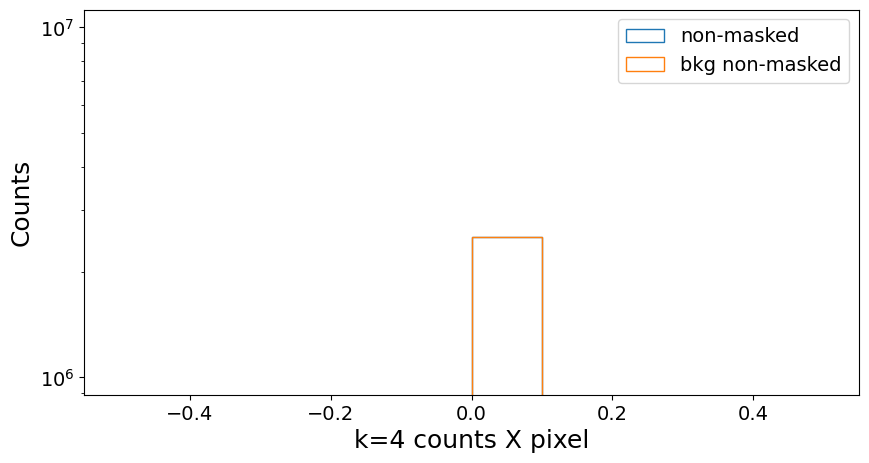

In [119]:
plt.figure(figsize=(10,5))

plt.hist(k_p[4]*k[1].shape[0],        bins=10, histtype='step', label='non-masked')
plt.hist(k_p_bkg[4]*k_bkg[1].shape[0], bins=10, histtype='step', label='bkg non-masked')

plt.xlabel('k=4 counts X pixel')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

# k-event statistic by frame
Envirormental noise can be seen within the k=2 high counts per px!
In reality all the images has noise, also the k=1.

## < k > (mean kounts per px)

In [333]:
k_mean = e4m_data_M.sum(axis=1)

k_f = {}
k_f[1] = k[1].sum(axis=1)
k_f[2] = k[2].sum(axis=1)
k_f[3] = k[3].sum(axis=1)
k_f[4] = k[4].sum(axis=1)

k_f_bkg = {}
k_f_bkg[1] = k_bkg[1].sum(axis=1)
k_f_bkg[2] = k_bkg[2].sum(axis=1)
k_f_bkg[3] = k_bkg[3].sum(axis=1)
k_f_bkg[4] = k_bkg[4].sum(axis=1)

if CR_removal:
    k_f_bkg_nocr = {}
    k_f_bkg_nocr[1] = k_bkg_nocr[1].sum(axis=1)
    k_f_bkg_nocr[2] = k_bkg_nocr[2].sum(axis=1)
    k_f_bkg_nocr[3] = k_bkg_nocr[3].sum(axis=1)
    k_f_bkg_nocr[4] = k_bkg_nocr[4].sum(axis=1)

    k_f_nocr = {}
    k_f_nocr[1] = k_nocr[1].sum(axis=1)
    k_f_nocr[2] = k_nocr[2].sum(axis=1)
    k_f_nocr[3] = k_nocr[3].sum(axis=1)
    k_f_nocr[3] = k_nocr[4].sum(axis=1)

Text(0.5, 0, '<k>')

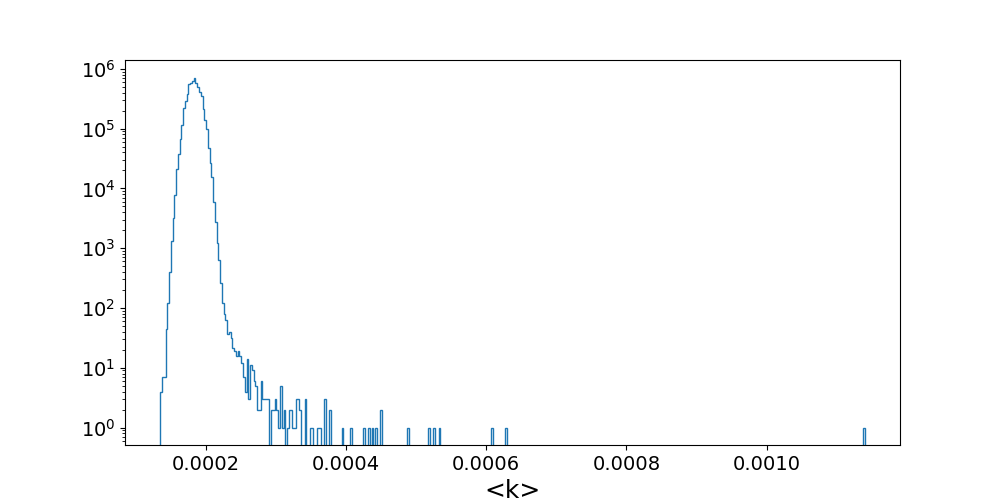

In [334]:
plt.figure(figsize=(10,5))
plt.hist(k_mean/M.sum(), bins=400, histtype='step',)
plt.yscale('log')
plt.xlabel('<k>')

## k=1

In [335]:
print('P(k=1) = ', k_f[1].sum()/(k[1].shape[0]*k[1].shape[1]))

P(k=1) =  0.0001828523143518005


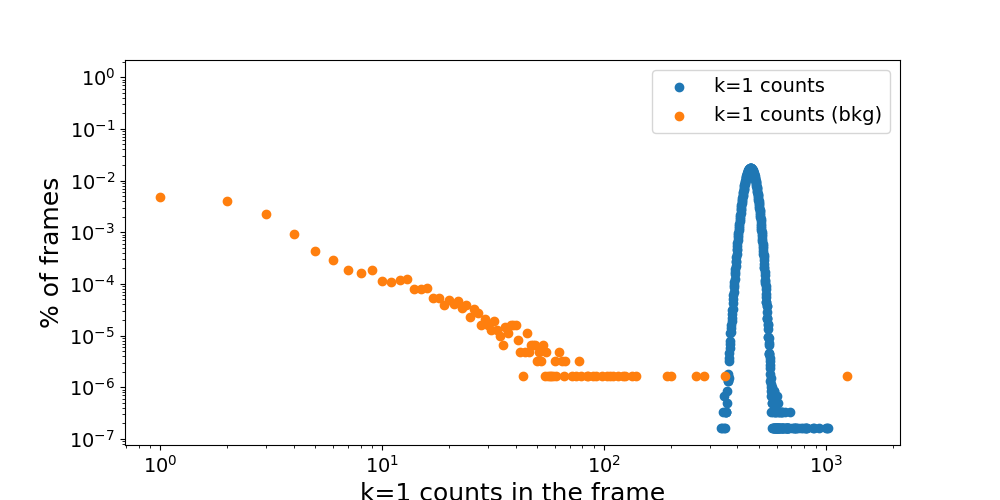

In [336]:
X = np.arange(0, 1500, 1)

plt.figure(figsize=(10,5))

Y = np.array([ (k_f[1]==i).sum() for i in X])
plt.scatter(X, Y/k[1].shape[0], label='k=1 counts')
if CR_removal:
    Y = np.array([ (k_f_nocr[1]==i).sum() for i in X])
    plt.scatter(X, Y/k[1].shape[0], label='k=1 counts (nocr)')

Y = np.array([ (k_f_bkg[1]==i).sum() for i in X])
plt.scatter(X, Y/k_bkg[1].shape[0], label='k=1 counts (bkg)')
if CR_removal:
    Y = np.array([ (k_f_bkg_nocr[1]==i).sum() for i in X])
    plt.scatter(X, Y/k_bkg[1].shape[0], label='k=1 counts (bkg nocr)')


plt.xlabel('k=1 counts in the frame')
plt.ylabel('% of frames')
plt.yscale('log')
plt.xscale('log')
plt.legend()

### k=1 sum img

In [337]:
k_bkg

{1: <Compressed Sparse Row sparse array of dtype 'bool'
 	with 42192 stored elements and shape (614270, 2507971)>,
 2: <Compressed Sparse Row sparse array of dtype 'bool'
 	with 9834 stored elements and shape (614270, 2507971)>,
 3: <Compressed Sparse Row sparse array of dtype 'bool'
 	with 0 stored elements and shape (614270, 2507971)>,
 4: <Compressed Sparse Row sparse array of dtype 'bool'
 	with 0 stored elements and shape (614270, 2507971)>}

Text(0.5, 1.0, 'Bkg k=1 sum img (614s)')

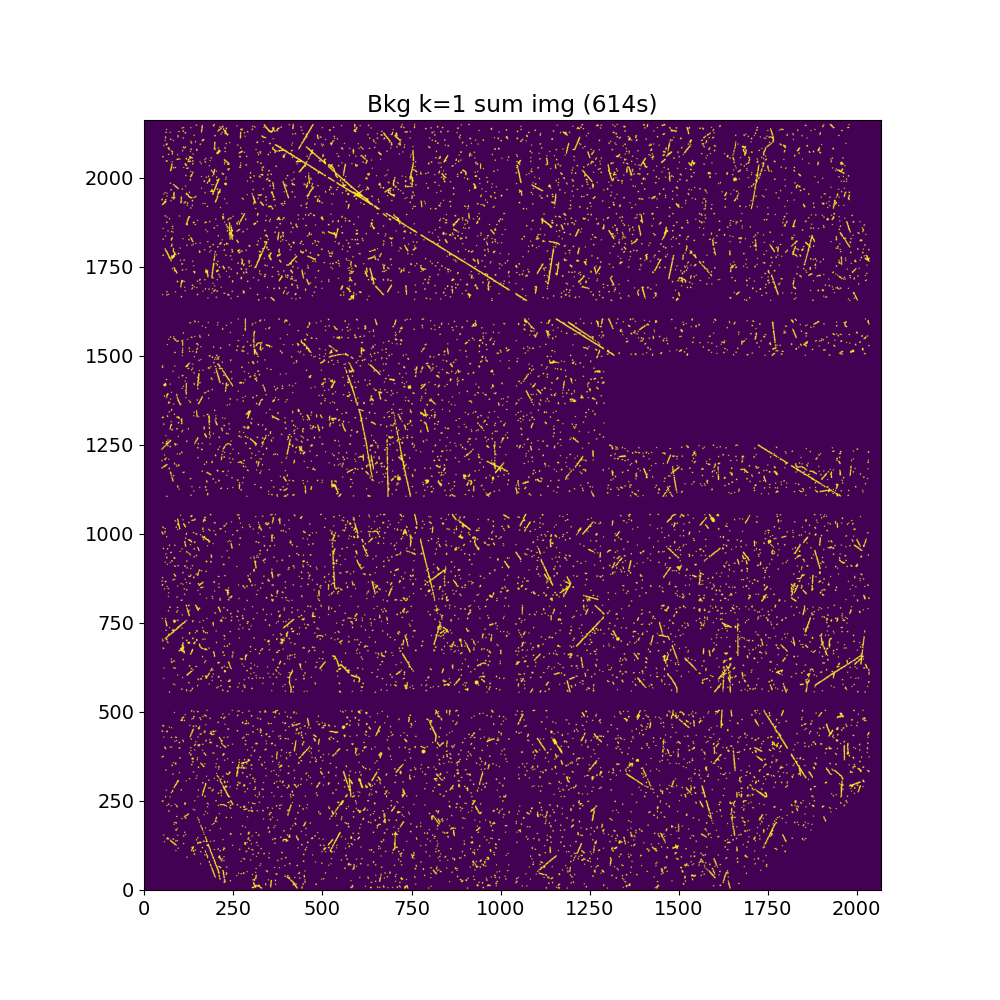

In [338]:
img = np.zeros_like(M)
img[M] = k_bkg[1].sum(axis=0)
img = img.reshape(Nx, Ny)
img = binary_dilation(img, structure=np.ones((3,3)), iterations=1)

plt.figure(figsize=(10,10))
plt.imshow(img, cmap='viridis', origin='lower', vmax=1)
plt.title(f'Bkg k=1 sum img ({k_bkg[1].shape[0]//1000}s)')

## k=2

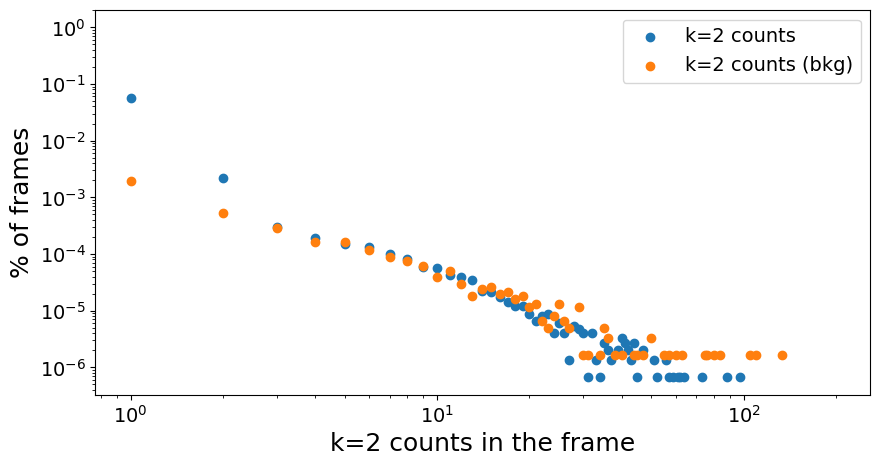

In [ ]:
X = np.arange(0, 200, 1)

plt.figure(figsize=(10,5))

Y = np.array([ (k_f[2]==i).sum() for i in X])
plt.scatter(X, Y/k[1].shape[0], label='k=2 counts')
if CR_removal:
    Y = np.array([ (k_f_nocr[2]==i).sum() for i in X])
    plt.scatter(X, Y/k[1].shape[0], label='k=2 counts (nocr)')

Y = np.array([ (k_f_bkg[2]==i).sum() for i in X])
plt.scatter(X, Y/k_bkg[1].shape[0], label='k=2 counts (bkg)')
if CR_removal:
    Y = np.array([ (k_f_bkg_nocr[2]==i).sum() for i in X])
    plt.scatter(X, Y/k_bkg[1].shape[0], label='k=2 counts (bkg no cr)')

plt.xlabel('k=2 counts in the frame')
plt.ylabel('% of frames')
plt.yscale('log')
plt.xscale('log')
plt.legend()

### k=2 sum img

Text(0.5, 1.0, 'Bkg k=2 sum img (1499s)')

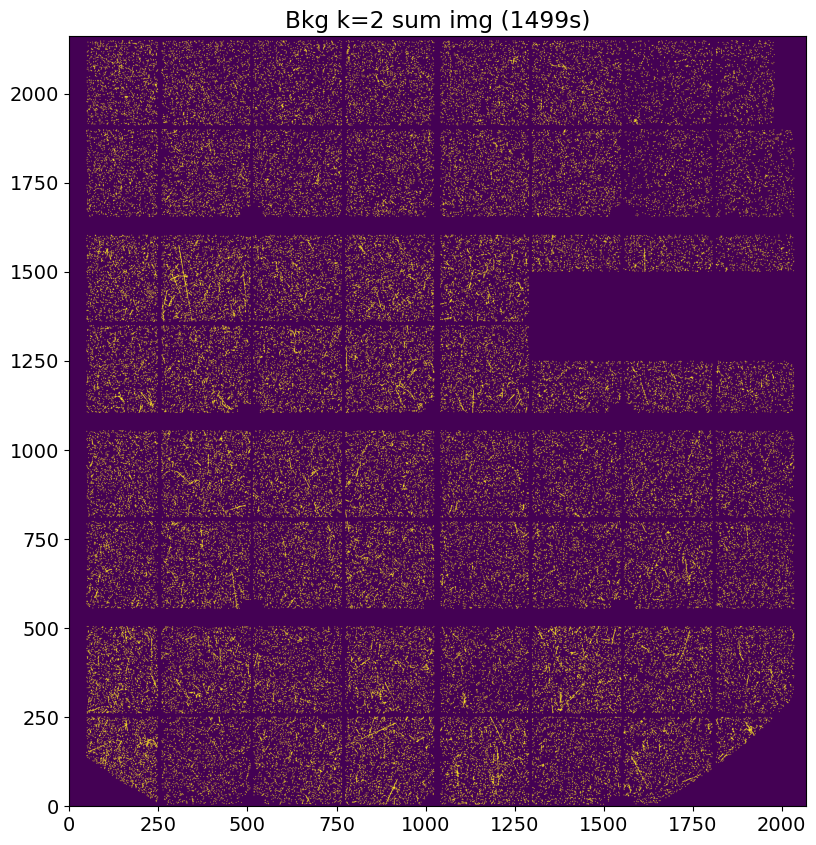

In [ ]:
img = np.zeros_like(M)
img[M] = k[2].sum(axis=0)
img = img.reshape(Nx, Ny)
img = binary_dilation(img, structure=np.ones((2,2)), iterations=1)

plt.figure(figsize=(10,10))
plt.imshow(img, cmap='viridis', origin='lower', vmax=1)
plt.title(f'Bkg k=2 sum img ({k[1].shape[0]//1000}s)')

Text(0.5, 1.0, 'Bkg k=2 sum img (614s)')

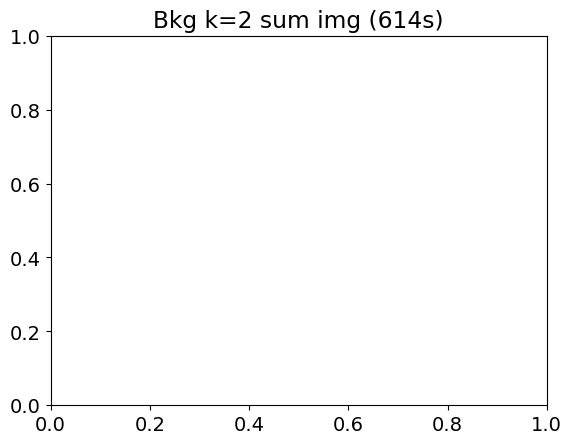

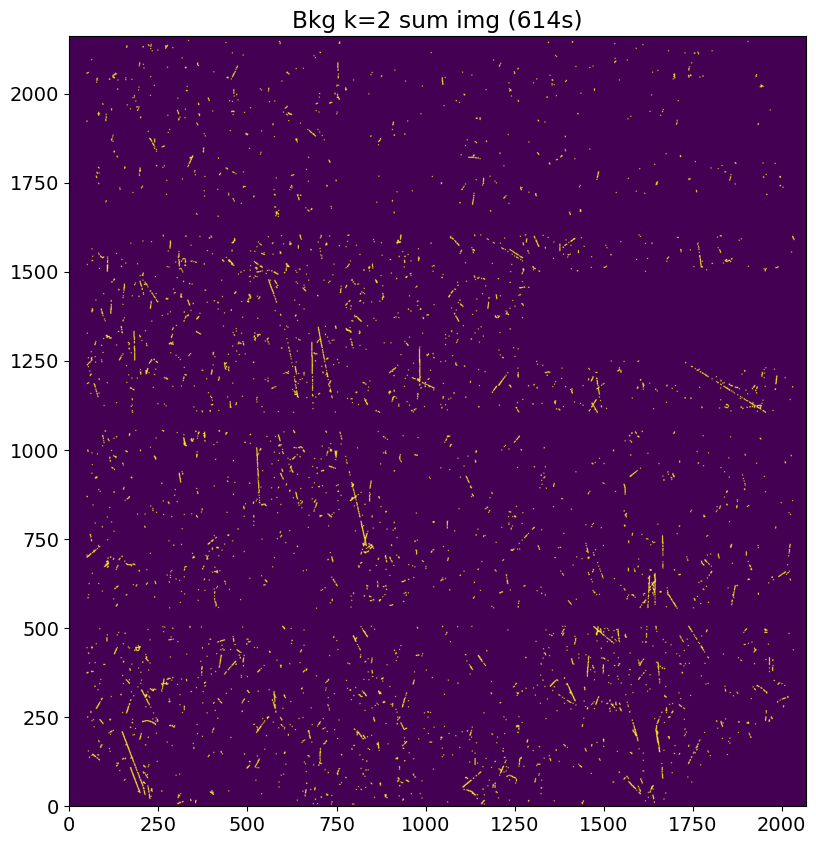

In [ ]:
img = np.zeros_like(M)
img[M] = k_bkg[2].sum(axis=0)
img = img.reshape(Nx, Ny)
img = binary_dilation(img, structure=np.ones((3,3)), iterations=1)
plt.title(f'Bkg k=2 sum img ({k_bkg[1].shape[0]//1000}s)')

plt.figure(figsize=(10,10))
plt.imshow(img, cmap='viridis', origin='lower', vmax=1)
plt.title(f'Bkg k=2 sum img ({k_bkg[1].shape[0]//1000}s)')

### k=2 selected images

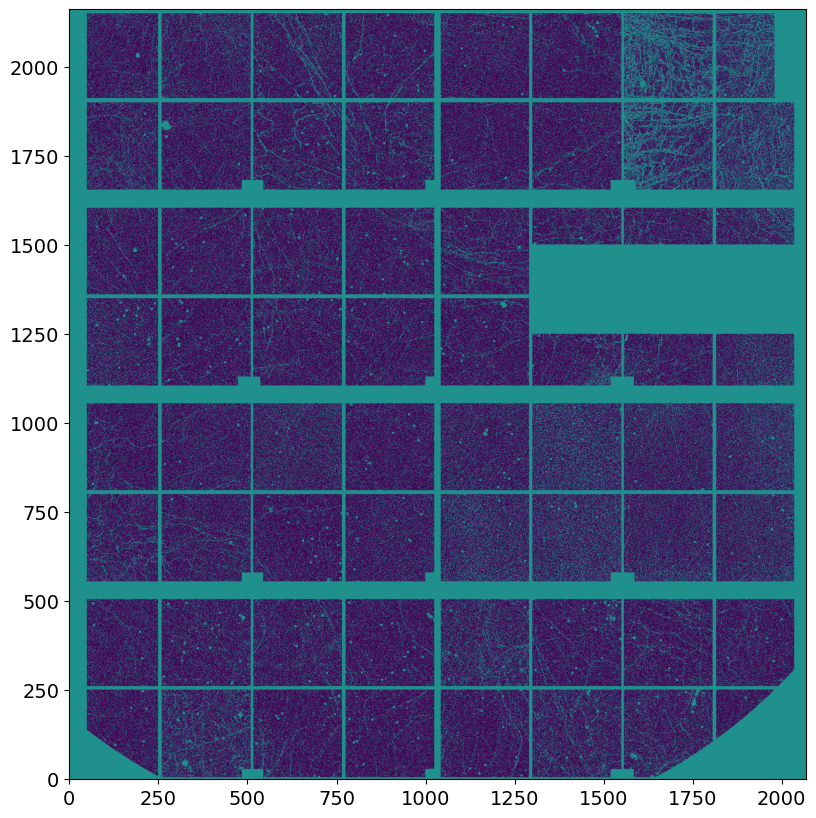

In [128]:
#######################################################
idxs = np.where(((k[2]).sum(axis=1) == 60))[0]
#######################################################

img = np.zeros_like(M)
img[M] = k[2][idxs].sum(axis=0)
img = img.reshape(Nx,Ny)
img = binary_dilation(img, structure=np.ones((5,5)), iterations=1)

plt.figure(figsize=(10,10))
plt.imshow(img + .5*~M.reshape(Nx,Ny), cmap='viridis', origin='lower', vmax=1)

## k=3

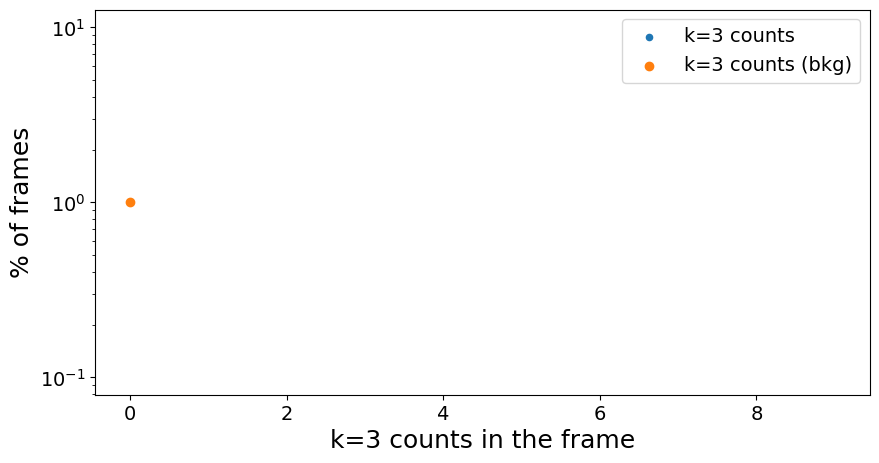

In [129]:
X = np.arange(0, 10, 1)

plt.figure(figsize=(10,5))

Y = np.array([ (k_f[3]==i).sum() for i in X])
plt.scatter(X, Y/k[1].shape[0], label='k=3 counts', s=20)
if CR_removal:
    Y = np.array([ (k_f_nocr[3]==i).sum() for i in X])
    plt.scatter(X, Y/k[1].shape[0], label='k=3 counts (nocr)')

Y = np.array([ (k_f_bkg[3]==i).sum() for i in X])
plt.scatter(X, Y/k_bkg[1].shape[0], label='k=3 counts (bkg)')
if CR_removal:
    Y = np.array([ (k_f_bkg_nocr[3]==i).sum() for i in X])
    plt.scatter(X, Y/k_bkg[1].shape[0], label='k=3 counts (bkg no cr)')

plt.xlabel('k=3 counts in the frame')
plt.ylabel('% of frames')
plt.yscale('log')
plt.legend()

### k=3 sum img

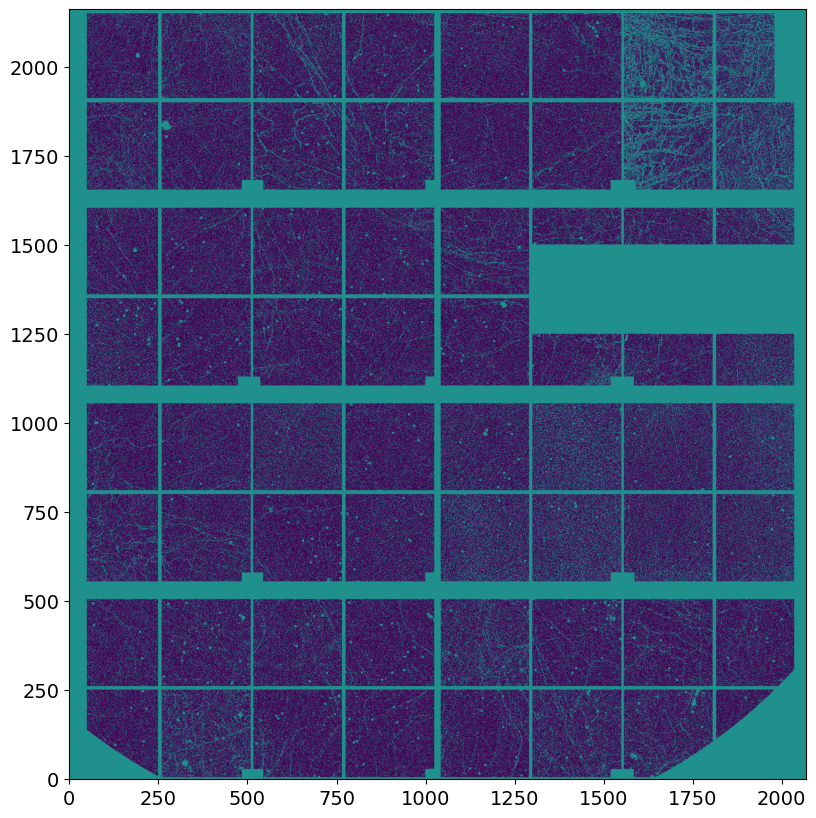

In [130]:
img = np.zeros_like(M)
img[M] = k[3].sum(axis=0)
img = img.reshape(Nx, Ny)
img = binary_dilation(img, structure=np.ones((7,7)), iterations=1)

plt.figure(figsize=(10,10))
plt.imshow(img+ .5*~M.reshape(Nx,Ny), cmap='viridis', origin='lower', vmax=1)

# Spackle visibility

### Qmask definition

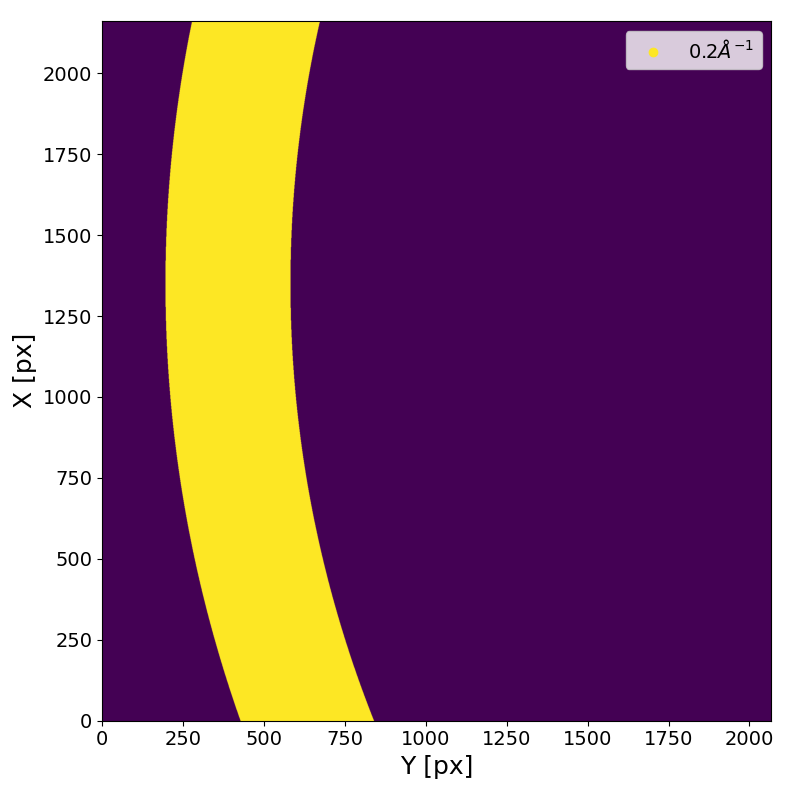

In [155]:
###################
Q = .2
dQ = .01
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Q, dQ, Qmap_plot=False)

## The calculation

In [242]:
from scipy.special import gamma, factorial

# Negative-Binomial distribution
NB_dist = lambda k, k_mean, beta: gamma(k+1/beta) / gamma(1/beta) / gamma(k+1) * (1+1/(k_mean*beta))**(-k) * (1+k_mean*beta)**(-1/beta)

# Poisson distibution
P_dist = lambda k, k_mean: np.exp(-k_mean) * k_mean**k / factorial(k)

In [249]:
################
Lbin = 1

Itp = e4m_data_M[:, Qmask[M]]
Itp_bkg = e4m_data_bkg_M[:, Qmask[M]]

Nfi = int(.5e6)
Nff = None

bin2dense = False
################

### Load & BIN data ###

# data (Itp)
Itp = Itp[Nfi:Nff]
Itp = XPCS.bin_Itp(Itp, Lbin=Lbin, bin2dense=bin2dense)
It = Itp.sum(axis=1)/Itp.shape[1]

# bkg (Itp_bkg)
if Itp_bkg is not None:
    if not isinstance(Itp, sparse.sparray):
        raise ValueError("Itp_bkg should not be a sparse array!")
    Itp_bkg = XPCS.bin_Itp(Itp_bkg, Lbin=Lbin)
    It_bkg = Itp_bkg.sum(axis=1)/Itp_bkg.shape[1]

Loading frames ...
Done! (elapsed time = 0.0 s)
Binning frames (Lbin = 1, using MKL library) ...
Done! (elapsed time = 1.2 s)
	 | 999240 frames X 547553 pixels
	 | sparsity = 2.14e-04
	 | memory usage (sparse.csr_array @ float32) = 1.315 GB
Loading frames ...
Done! (elapsed time = 0.0 s)
Binning frames (Lbin = 1, using MKL library) ...
Done! (elapsed time = 0.03 s)
	 | 614270 frames X 547553 pixels
	 | sparsity = 3.34e-08
	 | memory usage (sparse.csr_array @ float32) = 0.005 GB


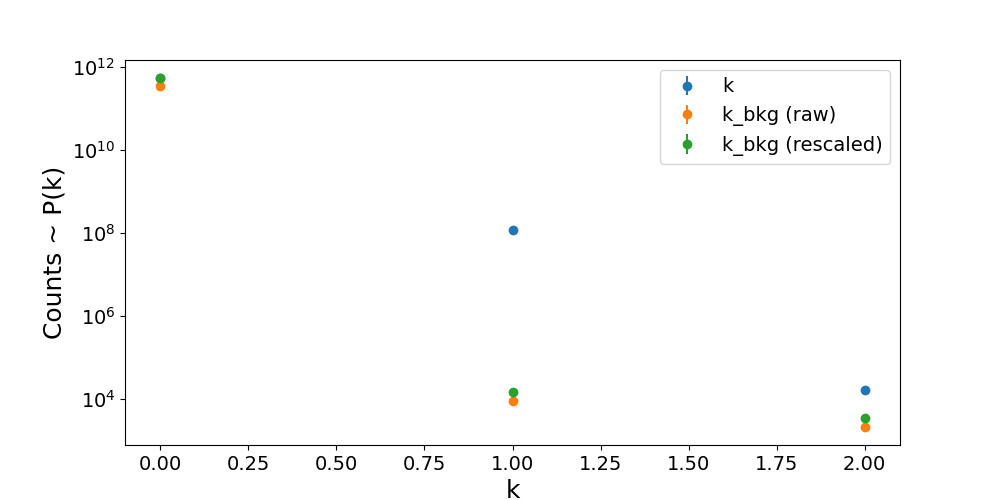

In [250]:
### COMPUTE K STATISTIC (k, k_bkg) ###

# data (k)
if isinstance(Itp, sparse.sparray):
    k = np.bincount(Itp.data.astype(int))
    k[0] = Itp.shape[0]*Itp.shape[1] - Itp.size
else:
    k = np.bincount(Itp.astype(int).flatten())

# bkg (k_bkg)
if Itp_bkg is not None:
    k_bkg = np.bincount(Itp_bkg.data.astype(int))
    k_bkg[0] = Itp_bkg.shape[0]*Itp_bkg.shape[1] - Itp_bkg.size

# plot
plt.figure(figsize=(10,5))
plt.errorbar(np.arange(k.size), k, yerr=np.sqrt(k), label='k', marker='o', linestyle='None')
if Itp_bkg is not None:
    plt.errorbar(np.arange(k_bkg.size), k_bkg, yerr=np.sqrt(k_bkg), label='k_bkg (raw)', marker='o', linestyle='None')
    plt.errorbar(np.arange(k_bkg.size), k_bkg/ Itp_bkg.shape[0]*Itp.shape[0], yerr=np.sqrt(k_bkg) / Itp_bkg.shape[0]*Itp.shape[0], label='k_bkg (rescaled)', marker='o', linestyle='None')
plt.xlabel('k')
plt.ylabel('Counts ~ P(k)')
plt.yscale('log')
plt.legend()
plt.show()

In [251]:
### COMPUTE P(k) (P, dP) ###
if Itp_bkg is not None:
    k_nobkg = k.copy()
    dk_nobkg = np.sqrt(k)

    i = np.min([k_nobkg.size, k_bkg.size])

    k_nobkg[1:i] -=  (k_bkg[1:i] / Itp_bkg.shape[0]*Itp.shape[0]).astype(int)
    k_nobkg[0]   +=  (k_bkg[1:i] / Itp_bkg.shape[0]*Itp.shape[0]).astype(int).sum()
    if Itp.shape[0]*Itp.shape[1] != k_nobkg.sum():
        raise ValueError("The size of k_nobkg does not match the expected size based on Itp dimensions.")
    
    dk_bkg = np.sqrt(k_bkg) / Itp_bkg.shape[0]*Itp.shape[0]
    dk_nobkg[1:i] = np.sqrt( np.sqrt(k[1:i])**2 + dk_bkg[1:i]**2)
    dk_nobkg[0]   = np.sqrt( np.sqrt(k[0])**2 + np.sum(dk_bkg[1:i]**2))

    P  = k_nobkg / k_nobkg.sum()
    dP = dk_nobkg/ k_nobkg.sum()
    dP[dP==0] = 1

elif Itp_bkg is None:
    P  = k / k.sum()
    dP = np.sqrt(k) / k.sum()
    dP[dP==0] = 1

In [252]:
It_bkg.mean()

np.float32(3.961107e-08)

k_mean_bkg = 3.9611069979628155e-08
k_mean = 0.0002138257834012336


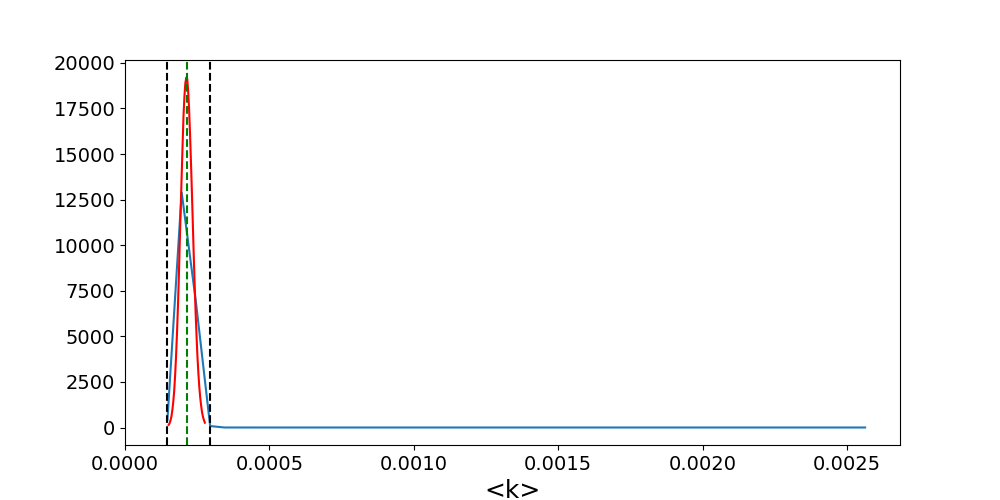

In [ ]:
### COMPUTE <k> (i.e. It_mean) & <k> DISTRIBUTION ( k_mean, k_mean_dist) ###

# <k>  
k_mean = It.mean().astype(np.float64)
if Itp_bkg is not None:
    k_mean_bkg = It_bkg.mean().astype(np.float64)
    k_mean -= k_mean_bkg
    print('k_mean_bkg =', k_mean_bkg)
print('k_mean =', k_mean)

# <K> PDF

# It histogram
if Itp_bkg is not None:
    counts, bin_edges = np.histogram(It-k_mean_bkg, bins=50, density=True)
else:
    counts, bin_edges = np.histogram(It, bins=50, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
if Itp_bkg is not None:
    bin_centers -= k_mean_bkg

# define the MAIN part of the histogram
idxs = np.where(counts>=counts.max()*0.001)[0]
It_min = bin_centers[idxs[0]]
It_max = bin_centers[idxs[-1]]

# <K> PDF
kde = gaussian_kde(It[(It >= k_mean-5*It.std()) & (It <= k_mean+5*It.std())])
X = np.linspace(k_mean-3*It.std(), k_mean+3*It.std(), 40)
PX = kde(X)
k_mean_dist = np.array((X, PX/PX.sum()))

### plot
plt.figure(figsize=(10,5))
plt.plot(bin_centers, counts)
plt.plot(X, PX, label='KDE', color='red')
plt.axvline(It_min, color='black', linestyle='--', label='It_min')
plt.axvline(It_max, color='black', linestyle='--', label='It_max)')
plt.axvline(k_mean, color='green', linestyle='--', label='<k> = {:.2f}'.format(k_mean))
plt.xlabel('<k>')
plt.xlim(0)
#plt.yscale('log')
plt.show()

chi2:
P       = 18.77
P_conv  = 18.17
NB      = 0.00
NB_conv = 5.73

beta:
NB      = 0.0515 ± 0.0119
NB_conv = 0.0416 ± 0.0118
01      = 0.0513 ± 0.4325
2       = 0.0513 ± 0.0136


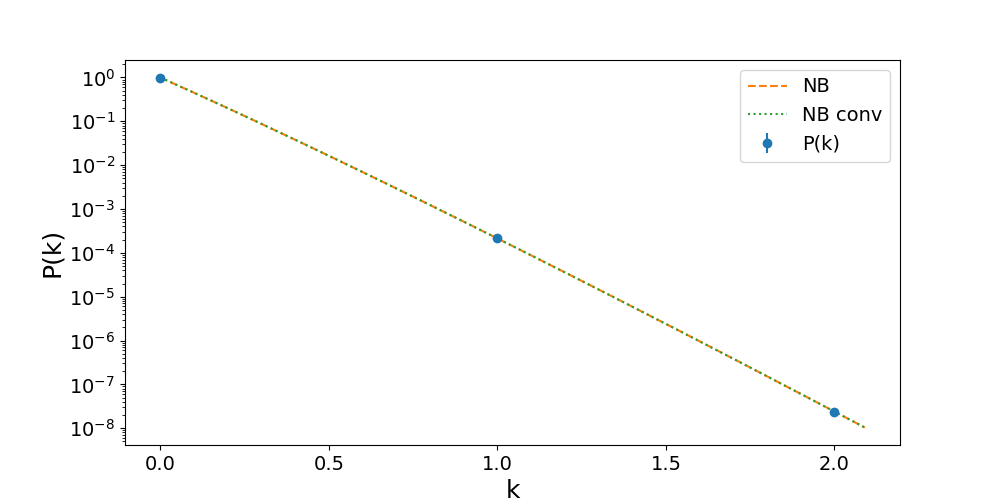

In [255]:
### FITS ###
chi2 ,beta, dbeta = {}, {}, {}

# DISTRIBUTIONS
P_dist_i  = lambda k: P_dist(k, k_mean)
NB_dist_i = lambda k, beta: NB_dist(k, k_mean, beta)
P_dist_conv_i = np.vectorize(lambda k: np.sum(P_dist(k, k_mean_dist[0]) * k_mean_dist[1]))
NB_dist_conv_i = np.vectorize(lambda k, beta: np.sum(NB_dist(k, k_mean_dist[0], beta) * k_mean_dist[1]))

# FIT POISSON DISTRIBUTION
chi2['P']= np.sum(((P_dist_i(np.arange(len(P))) - P)/dP)**2)

chi2['P_conv'] = np.sum(((P_dist_conv_i(np.arange(len(P))) - P)/dP)**2)

# FIT NB DISTRIBUTION
out = curve_fit(NB_dist_i, np.arange(len(P)), P, p0=[.01], sigma=dP, absolute_sigma=True, bounds=(0, 1))
beta['NB'], dbeta['NB'] = out[0][0], np.sqrt(out[1][0][0])
chi2['NB'] = np.sum(((NB_dist_i(np.arange(len(P)), beta['NB']) - P)/dP)**2)

out = curve_fit(NB_dist_conv_i, np.arange(len(P)), P, p0=[.01], sigma=dP, absolute_sigma=True, bounds=(0, 1))
beta['NB_conv'], dbeta['NB_conv'] = out[0][0], np.sqrt(out[1][0][0])
chi2['NB_conv'] = np.sum(((NB_dist_conv_i(np.arange(len(P)), beta['NB_conv']) - P)/dP)**2)

# FIT P(k) RATIOS
beta['01'] = P[0]/P[1] - 1/k_mean
dbeta['01'] = np.sqrt((dP[0]/P[1])**2 + (P[0]*dP[1]/P[1]**2)**2)

beta['2'] = 2*P[2]/k_mean**2 - 1
dbeta['2'] = np.sqrt((2*dP[2]/k_mean**2)**2 + (2*P[2]*dP[0]/k_mean**3)**2)

# print
print('chi2:')
print(f'P       = {chi2["P"]:.2f}')
print(f'P_conv  = {chi2["P_conv"]:.2f}')
print(f'NB      = {chi2["NB"]:.2f}')
print(f'NB_conv = {chi2['NB_conv']:.2f}')

print('\nbeta:')
print(f'NB      = {beta["NB"]:.4f} ± {dbeta["NB"]:.4f}')
print(f'NB_conv = {beta["NB_conv"]:.4f} ± {dbeta["NB_conv"]:.4f}')
print(f'01      = {beta["01"]:.4f} ± {dbeta["01"]:.4f}')
print(f'2       = {beta["2"]:.4f} ± {dbeta["2"]:.4f}')

# plot
plt.figure(figsize=(10,5))
plt.errorbar(np.arange(P.size), P, yerr=dP, label='P(k)', marker='o', linestyle='None')
X = np.arange(0, P.size-1+0.1, .01)
plt.plot(X, NB_dist_i(X, beta['NB']), label='NB', linestyle='--')
plt.plot(X, NB_dist_conv_i(X, beta['NB_conv']), label='NB conv', linestyle=':')

plt.xlabel('k')
plt.ylabel('P(k)')
plt.yscale('log')
plt.legend()
plt.show()

# XSVS script

In [365]:
import time
from sparse_dot_mkl import dot_product_mkl

def get_SV(e4m_data, depth, Nfi=None, Nff=None, mask=None, e4m_data_bkg=None, bkg_depth=10, Lbin2dense=1000, methods={'conv':True, '01':True, '2':True},):

    if Nfi == None: Nfi = 0
    if Nff == None: Nff = e4m_data.shape[0]

    #check if e4m_data, e4m_data_bkg, and mask have the same size
    if e4m_data_bkg is not None and e4m_data_bkg.shape[1] != e4m_data.shape[1]:
        raise ValueError("e4m_data_bkg and e4m_data must have the same number of pixels.")
    if mask is not None and mask.shape[0] != e4m_data.shape[1]:
        raise ValueError("mask must have the same number of pixels as e4m_data.")
    if e4m_data_bkg is not None and mask is not None and e4m_data_bkg.shape[1] != mask.shape[0]:
        raise ValueError("e4m_data_bkg and mask must have the same number of pixels.")

    #  LOAD DATA
    t0 = time.time()
    print('Loading frames ...')
    if (Nfi!=0) or (Nff!=e4m_data.shape[0]): Itp = e4m_data[Nfi:Nff]
    else : Itp = e4m_data
    # convert to float32
    if Itp.dtype != np.float32: Itp = Itp.astype(np.float32)
    # done
    print('Done! (elapsed time =', round(time.time()-t0, 2), 's)')
    print('\t | '+str(Itp.shape[0])+' frames X '+str(Itp.shape[1])+' pixels')
    if isinstance(Itp, sparse.sparray):
        print('\t | sparsity = {:.2e}'.format(Itp.data.size/(Itp.shape[0]*Itp.shape[1])))
        print('\t | memory usage (sparse.csr_array @ '+str(Itp.dtype)+') =', round((Itp.data.nbytes+Itp.indices.nbytes+Itp.indptr.nbytes)/1024**3,3), 'GB')
    else:
        print('\t | memory usage (np.array @ '+str(Itp.dtype)+') =', round(Itp.nbytes/1024**3,3), 'GB')


    #  MASK DATA
    if mask is not None:
        t0 = time.time()
        print('Masking data ...')
        Itp = Itp[:,mask]
        #done
        print('Done! (elapsed time =', round(time.time()-t0, 2), 's)')
        print('\t | '+str(Itp.shape[0])+' frames X '+str(Itp.shape[1])+' pixels')
        if isinstance(Itp, sparse.sparray):
            print('\t | sparsity = {:.2e}'.format(Itp.data.size/(Itp.shape[0]*Itp.shape[1])))
            print('\t | memory usage (sparse.csr_array @ '+str(Itp.dtype)+') =', round((Itp.data.nbytes+Itp.indices.nbytes+Itp.indptr.nbytes)/1024**3,3), 'GB')
        else:
            print('\t | memory usage (np.array @ '+str(Itp.dtype)+') =', round(Itp.nbytes/1024**3,3), 'GB')
    
    # LOAD & MASK BKG DATA
    if e4m_data_bkg is not None:
        t0 = time.time()
        print('Loading bkg frames ...')
        if (Nfi!=0) or (Nff!=e4m_data_bkg.shape[0]): Itp_bkg = e4m_data_bkg[Nfi:Nff]
        else : Itp_bkg = e4m_data_bkg
        # convert to float32
        if Itp_bkg.dtype != np.float32: Itp_bkg = Itp_bkg.astype(np.float32)
        #  mask bkg data
        if mask is not None:
            t0 = time.time()
            print('Masking bkg data ...')
            Itp_bkg = Itp_bkg[:,mask]
        #done
        print('Done! (elapsed time =', round(time.time()-t0, 2), 's)')
        print('\t | '+str(Itp_bkg.shape[0])+' frames X '+str(Itp_bkg.shape[1])+' pixels')
        if isinstance(Itp_bkg, sparse.sparray):
            print('\t | sparsity = {:.2e}'.format(Itp_bkg.data.size/(Itp_bkg.shape[0]*Itp_bkg.shape[1])))
            print('\t | memory usage (sparse.csr_array @ '+str(Itp_bkg.dtype)+') =', round((Itp_bkg.data.nbytes+Itp_bkg.indices.nbytes+Itp_bkg.indptr.nbytes)/1024**3,3), 'GB')
        else:
            print('\t | memory usage (np.array @ '+str(Itp_bkg.dtype)+') =', round(Itp_bkg.nbytes/1024**3,3), 'GB')

    # Compute It
    It = Itp.sum(axis=1)/Itp.shape[1]
    if e4m_data_bkg is not None:
        It_bkg = Itp_bkg.sum(axis=1)/Itp_bkg.shape[1]

    # THE XSVS CYCLE
    fitout = pd.DataFrame(columns=['k_mean', 'chi2_P', 'chi2_P_conv', 'chi2_NB', 'chi2_NB_conv', 'beta_NB', 'dbeta_NB', 'beta_NB_conv', 'dbeta_NB_conv', 'beta_01', 'dbeta_01', 'beta_2', 'dbeta_2'],)
    fitout.index.name = 'T'
    T = 2**np.arange(depth)

    t0 = time.time()
    for l in range(len(T)):
        print(f'Computing SV for T = {T[l]} ...')

        ### BIN DATA  ###
        if l!=0:
            # data (Itp)
            if T[l]>Lbin2dense:
                bin2dense = True
                print('\t | Binning data (to dense matrix) ...')
            else:
                bin2dense = False
                print('\t | Binning data (to sparse matrix) ...')
            Itp = (Itp[:Itp.shape[0]//2*2]) # throw the last frames 
            BIN_matrix = sparse.csr_array((np.ones(Itp.shape[0]), (np.arange(Itp.shape[0])//2, np.arange(Itp.shape[0]))), dtype=np.float32)
            Itp = dot_product_mkl(BIN_matrix, Itp, dense=bin2dense)
            It = Itp.sum(axis=1)/Itp.shape[1]

            # bkg (Itp_bkg)
            if (e4m_data_bkg is not None) and (l<bkg_depth):
                if not isinstance(Itp_bkg, sparse.sparray):
                    raise ValueError("Itp_bkg should be a sparse array!")
                print('\t | Binning bkg data (to sparse matrix) ...')
                Itp_bkg = (Itp_bkg[:Itp_bkg.shape[0]//2*2])
                BIN_matrix = sparse.csr_array((np.ones(Itp_bkg.shape[0]), (np.arange(Itp_bkg.shape[0])//2, np.arange(Itp_bkg.shape[0]))), dtype=np.float32)
                Itp_bkg = dot_product_mkl(BIN_matrix, Itp_bkg, dense=False)
                It_bkg = Itp_bkg.sum(axis=1)/Itp_bkg.shape[1]

        ### COMPUTE K STATISTIC (k, k_bkg) ###

        # data (k)
        print('\t | Computing k-statistic ...')
        if isinstance(Itp, sparse.sparray):
            k = np.bincount(Itp.data.astype(int))
            k[0] = Itp.shape[0]*Itp.shape[1] - Itp.size
        else:
            k = np.bincount(Itp.astype(int).flatten())
        
        # bkg (k_bkg)
        if (e4m_data_bkg is not None) and (l<bkg_depth):
            k_bkg = np.bincount(Itp_bkg.data.astype(int))
            k_bkg[0] = Itp_bkg.shape[0]*Itp_bkg.shape[1] - Itp_bkg.size


        ### COMPUTE P(k) (P, dP) ###
        if (e4m_data_bkg is not None) and (l<bkg_depth):
            k_nobkg = k.copy()
            dk_nobkg = np.sqrt(k)

            i = np.min([k_nobkg.size, k_bkg.size])

            k_nobkg[1:i] -=  (k_bkg[1:i] / Itp_bkg.shape[0]*Itp.shape[0]).astype(int)
            k_nobkg[0]   +=  (k_bkg[1:i] / Itp_bkg.shape[0]*Itp.shape[0]).astype(int).sum()
            if Itp.shape[0]*Itp.shape[1] != k_nobkg.sum():
                raise ValueError("The size of k_nobkg does not match the expected size based on Itp dimensions.")
            
            dk_bkg = np.sqrt(k_bkg) / Itp_bkg.shape[0]*Itp.shape[0]
            dk_nobkg[1:i] = np.sqrt( np.sqrt(k[1:i])**2 + dk_bkg[1:i]**2)
            dk_nobkg[0]   = np.sqrt( np.sqrt(k[0])**2 + np.sum(dk_bkg[1:i]**2))

            P  = k_nobkg / k_nobkg.sum()
            dP = dk_nobkg/ k_nobkg.sum()
            dP[dP==0] = 1

        else:
            P  = k / k.sum()
            dP = np.sqrt(k) / k.sum()
            dP[dP==0] = 1

        ### COMPUTE <k> (i.e. It_mean) & <k> DISTRIBUTION ( k_mean, k_mean_dist) ###

        # <k> 
        k_mean = It.mean().astype(np.float64)
        if (e4m_data_bkg is not None) and (l<bkg_depth):
            k_mean_bkg = It_bkg.mean().astype(np.float64)
            k_mean -= k_mean_bkg
        print(f'\t |\t-> k_mean = {k_mean:.6f}')

        
        # <K> PDF
        if methods['conv']:
            # It histogram
            if (e4m_data_bkg is not None) and (l<bkg_depth):
                counts, bin_edges = np.histogram(It-k_mean_bkg, bins=50, density=True)
            else:
                counts, bin_edges = np.histogram(It, bins=50, density=True)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            if (e4m_data_bkg is not None) and (l<bkg_depth):
                bin_centers -= k_mean_bkg
            # <K> PDF
            kde = gaussian_kde(It[(It >= k_mean-5*It.std()) & (It <= k_mean+5*It.std())])
            X = np.linspace(k_mean-3*It.std(), k_mean+3*It.std(), 40)
            PX = kde(X)
            k_mean_dist = np.array((X, PX/PX.sum()))

        ### FITS ###
        print('\t | Fitting distributions ...')
        chi2, beta, dbeta = {}, {}, {}

        # DISTRIBUTIONS
        P_dist_i  = lambda k: P_dist(k, k_mean)
        NB_dist_i = lambda k, beta: NB_dist(k, k_mean, beta)
        if methods['conv']:
            P_dist_conv_i = np.vectorize(lambda k: np.sum(P_dist(k, k_mean_dist[0]) * k_mean_dist[1]))
            NB_dist_conv_i = np.vectorize(lambda k, beta: np.sum(NB_dist(k, k_mean_dist[0], beta) * k_mean_dist[1]))
        

        # FIT POISSON DISTRIBUTION
        chi2['P']= np.sum(((P_dist_i(np.arange(len(P))) - P)/dP)**2)/(len(P)-1)
        if methods['conv']: chi2['P_conv'] = np.sum(((P_dist_conv_i(np.arange(len(P))) - P)/dP)**2)/(len(P))
        #else:
        #    chi2['P_conv'] = np.nan

        ### FIT NB DISTRIBUTION ###
        out = curve_fit(NB_dist_i, np.arange(len(P)), P, p0=[.1], sigma=dP, absolute_sigma=True, bounds=(.006, 1))
        beta['NB'], dbeta['NB'] = out[0][0], np.sqrt(out[1][0][0])
        chi2['NB'] = np.sum(((NB_dist_i(np.arange(len(P)), beta['NB']) - P)/dP)**2)/(len(P)-1)

        if methods['conv']:
            out = curve_fit(NB_dist_conv_i, np.arange(len(P)), P, p0=[.1], sigma=dP, absolute_sigma=True, bounds=(.006, 1))
            beta['NB_conv'], dbeta['NB_conv'] = out[0][0], np.sqrt(out[1][0][0])
            chi2['NB_conv'] = np.sum(((NB_dist_conv_i(np.arange(len(P)), beta['NB_conv']) - P)/dP)**2)/(len(P)-1)
        else:
            beta['NB_conv'] = np.nan
            chi2['NB_conv'] = np.nan

        ### FIT P(k) RATIOS ###
        if methods['01']:
            beta['01'] = P[0]/P[1] - 1/k_mean
            dbeta['01'] = np.sqrt((dP[0]/P[1])**2 + (P[0]*dP[1]/P[1]**2)**2)
        else:
            beta['01'] = np.nan
            dbeta['01'] = np.nan
        
        if methods['2']:
            beta['2'] = 2*P[2]/k_mean**2 - 1
            dbeta['2'] = np.sqrt((2*dP[2]/k_mean**2)**2 + (2*P[2]*dP[0]/k_mean**3)**2)
        else:
            beta['2'] = np.nan
            dbeta['2'] = np.nan

        fitout.loc[T[l]] = [k_mean, chi2['P'], chi2['P_conv'], chi2['NB'], chi2['NB_conv'], beta['NB'], dbeta['NB'], beta['NB_conv'], dbeta['NB_conv'], beta['01'], dbeta['01'], beta['2'], dbeta['2']]

        print('Done! (elapsed time =', round(time.time()-t0, 2), 's)')
        print(f'\t |\t-> chi2_P = {chi2["P"]:.2f}, chi2_P_conv = {chi2["P_conv"]:.2f}, chi2_NB = {chi2["NB"]:.2f}, chi2_NB_conv = {chi2["NB_conv"]:.2f}')
        print(f'\t |\t-> beta_NB = {beta["NB"]:.4f} ± {dbeta["NB"]:.4f}, beta_NB_conv = {beta["NB_conv"]:.4f} ± {dbeta["NB_conv"]:.4f}, beta_01 = {beta["01"]:.4f} ± {dbeta["01"]:.4f}, beta_2 = {beta["2"]:.4f} ± {dbeta["2"]:.4f}')

    return fitout

In [366]:
################
Itp = e4m_data_M[:, Qmask[M]]
Itp_bkg = e4m_data_bkg_M[:, Qmask[M]]
Nfi = int(.5e6)
Nff = None
mask = None
Lbin2dense = 500
################

fitout = get_SV(Itp, depth=16, Nfi=Nfi, Nff=Nff, e4m_data_bkg=Itp_bkg, methods={'conv':True, '01':True, '2':False}, bkg_depth=100)

Loading frames ...
Done! (elapsed time = 40.6 s)
	 | 5499048 frames X 548641 pixels
	 | sparsity = 1.77e-04
	 | memory usage (sparse.csr_array @ float32) = 6.008 GB
Loading bkg frames ...
Done! (elapsed time = 0.0 s)
	 | 114270 frames X 548641 pixels
	 | sparsity = 3.00e-08
	 | memory usage (sparse.csr_array @ float32) = 0.001 GB
Computing SV for T = 1 ...
	 | Computing k-statistic ...
	 |	-> k_mean = 0.000177
	 | Fitting distributions ...
Done! (elapsed time = 26.02 s)
	 |	-> chi2_P = 16.58, chi2_P_conv = 60.88, chi2_NB = 16.78, chi2_NB_conv = 122.31
	 |	-> beta_NB = 0.0060 ± 0.2377, beta_NB_conv = 0.0060 ± 0.2422, beta_01 = -1.0002 ± 0.2456, beta_2 = nan ± nan
Computing SV for T = 2 ...
	 | Binning data (to sparse matrix) ...
	 | Binning bkg data (to sparse matrix) ...
	 | Computing k-statistic ...
	 |	-> k_mean = 0.000354
	 | Fitting distributions ...
Done! (elapsed time = 124.76 s)
	 |	-> chi2_P = 21760.97, chi2_P_conv = 14843.00, chi2_NB = 22300.74, chi2_NB_conv = 22813.44
	 |	-> 

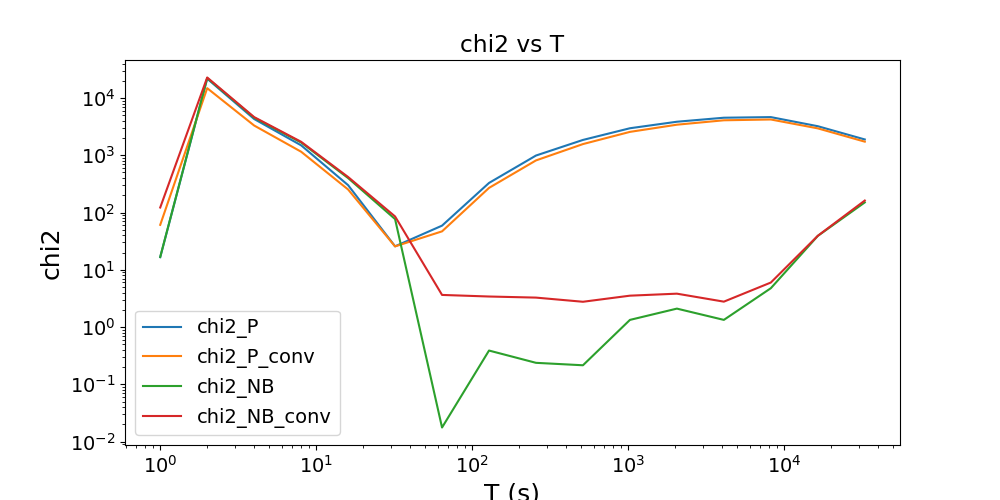

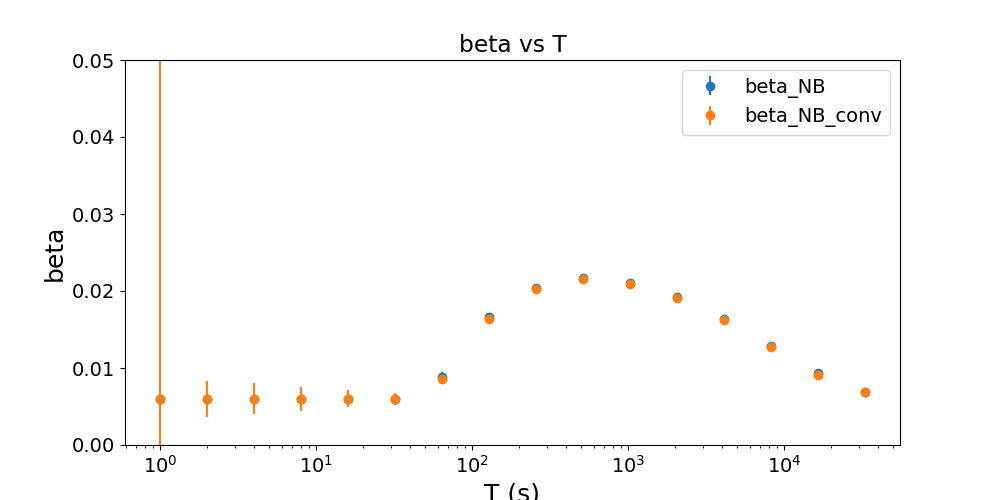

In [368]:
plt.figure(figsize=(10,5))
plt.title('chi2 vs T')
plt.plot(fitout.index, fitout['chi2_P'], label='chi2_P')
plt.plot(fitout.index, fitout['chi2_P_conv'], label='chi2_P_conv')
plt.plot(fitout.index, fitout['chi2_NB'], label='chi2_NB')
plt.plot(fitout.index, fitout['chi2_NB_conv'], label='chi2_NB_conv')

plt.xlabel('T (s)')
plt.ylabel('chi2')
plt.yscale('log')
plt.legend()
plt.xscale('log')
plt.show()

plt.figure(figsize=(10,5))
plt.title('beta vs T')

plt.errorbar(fitout.index, fitout['beta_NB'], yerr=fitout['dbeta_NB'], label='beta_NB', marker='o', linestyle='None')
plt.errorbar(fitout.index, fitout['beta_NB_conv'], yerr=fitout['dbeta_NB_conv'], label='beta_NB_conv', marker='o', linestyle='None')
#plt.errorbar(fitout.index, fitout['beta_01'], yerr=fitout['dbeta_01'], label='beta_01', marker='o', linestyle='None')
#plt.errorbar(fitout.index, fitout['beta_2'], yerr=fitout['dbeta_2'], label='beta_2', marker='o', linestyle='None')

plt.xlabel('T (s)')
plt.ylabel('beta')
plt.ylim(0,.05)
#plt.xlim(100)Lbin[l]Itp_bkg is None
plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.show()

# A look to the correlation functions

In [ ]:
%%HTML
##### INPUTS #####
sparse_depth = 14
ch_depth = 4
mask = e4m_mask*bs_mask*e4m_kmask
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=int(.5e6), Nff=int(.5e6+2**18))
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask*e4m_htmask, Nfi=int(.5e6), Nff=int(.5e6+2**18))
g2mt_ht= np.vstack(XPCS.get_g2mt(itime, G2tmt))

# G2tmt = XPCS.get_G2tmt_4sparse(e4m_data_nocr, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=int(.5e6), Nff=int(.5e6+2**18))
# g2mt_nocr = np.vstack(XPCS.get_g2mt(itime, G2tmt))

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data_bkg, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=None, Nff=int(2**18))
g2mt_bkg = np.vstack(XPCS.get_g2mt(itime_bkg, G2tmt))

# G2tmt = XPCS.get_G2tmt_4sparse(e4m_data_bkg_nocr, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=None, Nff=int(2**18))
# g2mt_bkg_nocr = np.vstack(XPCS.get_g2mt(itime_bkg, G2tmt))


In [ ]:
%%HTML
plt.figure(figsize=(10,5))

plt.errorbar(g2mt[0], g2mt[1], yerr=g2mt[2], fmt='o', label='g2mt')
#plt.errorbar(g2mt_nocr[0], g2mt_nocr[1], yerr=g2mt_nocr[2], fmt='o', label='g2mt (no cr)')
plt.errorbar(g2mt_ht[0], g2mt_ht[1], yerr=g2mt_ht[2], fmt='o', label='g2mt htmask')

plt.xscale('log')
plt.legend()

In [ ]:
%%HTML
plt.figure(figsize=(10,5))

plt.errorbar(g2mt_bkg[0], g2mt_bkg[1], yerr=g2mt_bkg[2], fmt='o', label='g2mt bkg')
#plt.errorbar(g2mt_bkg_nocr[0], g2mt_bkg_nocr[1], yerr=g2mt_bkg_nocr[2], fmt='o', label='g2mt bkg (no cr)')

plt.xscale('log')
#plt.ylim(0,1.1)